# 🌳 Decision Tree in Machine Learning

### Intuition → Practice → Math

Bugungi darsda biz Decision Tree ni 3 qatlamda tushunamiz:

- 🧠 Intuition (hayotiy misollar)
- 🧪 Practice (sklearn + vizual)
- 📐 Mathematics (entropy, gini, IG)

👉 Maqsad: “modelni ishlatish emas, uni tushunish”

## 🧠 1. Decision Tree nima?

Decision Tree — bu **ketma-ket savollar orqali qaror qabul qiladigan model**.

U inson fikrlashiga o‘xshaydi.

## 🌤 2. Tennis o‘ynaymizmi?

Features:
- weather
- humidity
- wind

Label:
- play (yes / no)

👉 Model savollar orqali data ni bo‘lib chiqadi.

![Tennis Data](tennis_play_data.png)

![Decision Tree](tennis_play_no_tree.png)

## 4. Tree qanday ishlaydi?

Decision Tree har bir bosqichda shunday savol beradi:

- Qaysi feature bo‘yicha bo‘lsam data eng yaxshi ajraladi?
- Qaysi split dan keyin tugunlar eng toza bo‘ladi?

Shu sababli u doim eng yaxshi savolni tanlashga harakat qiladi.

Masalan:

- `weather = sunny?`
- `humidity = high?`
- `wind = strong?`

Har bir savol data ni kichikroq va aniqroq guruhlarga bo‘ladi.

## 5. Root, internal node va leaf

Daraxtning uchta asosiy qismi bor:

- **root node** — boshlang‘ich tugun
- **internal node** — oraliq savol tuguni
- **leaf** — yakuniy natija

Misol:

Agar daraxtda quyidagi yo‘l bo‘lsa:

- weather = sunny
- humidity = high
- play = no

unda oxirgi javob chiqadigan joy — `leaf`.

Daraxt chuqurlashgani sari u ko‘proq qoidalarni o‘rganadi.
Lekin daraxt juda chuqur bo‘lsa, u `overfitting` qilishi mumkin.

In [26]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({
    'weather': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny'],
    'humidity': ['high', 'high', 'high', 'high', 'normal', 'normal', 'normal', 'high'],
    'wind': ['weak', 'strong', 'weak', 'weak', 'weak', 'strong', 'strong', 'weak'],
    'play': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no']
})
encoded_data = data.copy()
encoders = {}
for col in ['weather', 'humidity', 'wind', 'play']:
    le = LabelEncoder()
    encoded_data[col] = le.fit_transform(encoded_data[col])
    encoders[col] = le

![Encoded data](tennis_data_encode.png)

## 15. Nega categorical data ni kodlaymiz?

`sklearn` tree modellari sonli input bilan ishlaydi.

Shuning uchun kategoriyalarni raqamlarga o‘tkazamiz:

- `Sunny` → 0 yoki 1 yoki 2
- `Rain` → boshqa raqam
- `Overcast` → boshqa raqam

Buni `LabelEncoder` yordamida qilamiz.

Muhim:
bu kodlash faqat modelga qulay format beradi.
Asl ma’no kategoriyaviyligicha qoladi.


## 17. Tree visualization

`plot_tree` yordamida model ichida nima bo‘layotganini ko‘ramiz.

Vizualda quyidagilarni kuzatamiz:

- `samples`
- `value`
- `gini` yoki `entropy`
- `class`
- split shartlari

Bu rasm juda muhim, chunki u modelni “qora quti” dan ko‘ra tushunarli qiladi.

In [27]:
X_toy = encoded_data[['weather', 'humidity', 'wind']]
y_toy = encoded_data['play']

In [28]:
from sklearn.tree import DecisionTreeClassifier

toy_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

toy_model.fit(X_toy, y_toy)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

## 16. Modelni o‘qitish

Endi `DecisionTreeClassifier` ni o‘qitamiz.

Bu yerda quyidagi parametrlar muhim:

- `criterion='entropy'` yoki `criterion='gini'`
- `max_depth`
- `random_state`

Agar `max_depth` katta bo‘lsa, daraxt murakkablashadi.
Agar `max_depth` kichik bo‘lsa, daraxt soddaroq bo‘ladi.

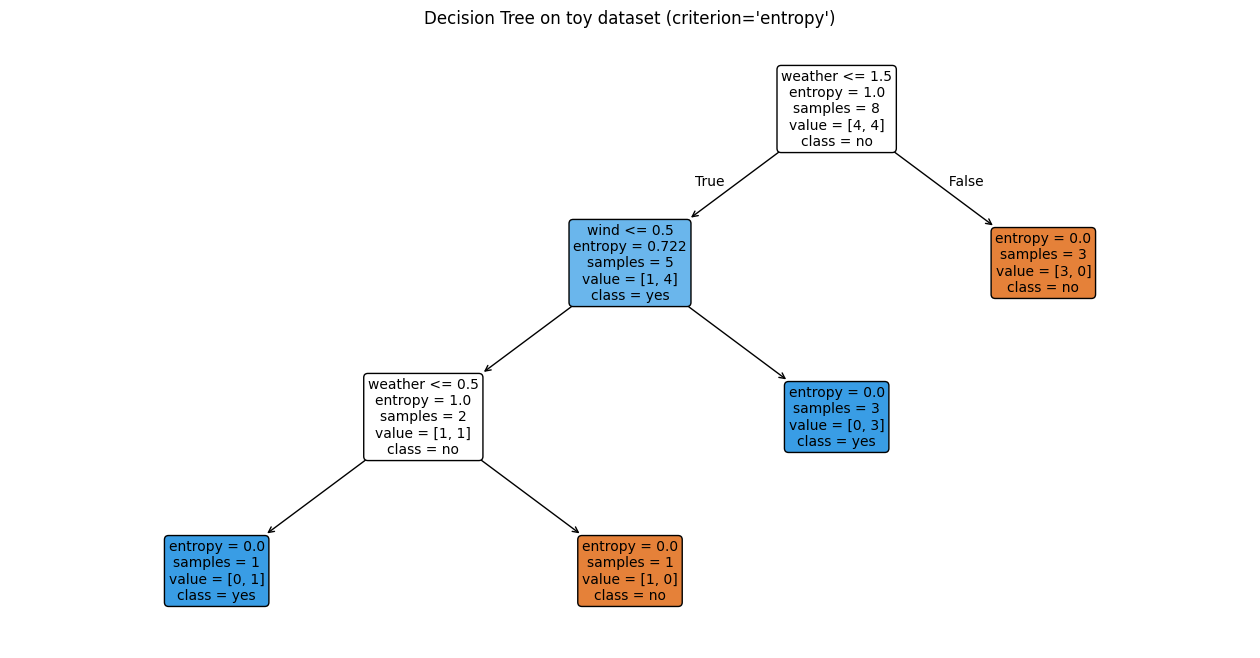

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    toy_model,
    feature_names=['weather', 'humidity', 'wind'],
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree on toy dataset (criterion='entropy')")
plt.show()

## 17. Tree visualization

`plot_tree` yordamida model ichida nima bo‘layotganini ko‘ramiz.

Vizualda quyidagilarni kuzatamiz:

- `samples`
- `value`
- `gini` yoki `entropy`
- `class`
- split shartlari

Bu rasm juda muhim, chunki u modelni “qora quti” dan ko‘ra tushunarli qiladi.

In [30]:
X_toy = encoded_data[['weather', 'humidity', 'wind']]
y_toy = encoded_data['play']

In [31]:
encoders

{'weather': LabelEncoder(),
 'humidity': LabelEncoder(),
 'wind': LabelEncoder(),
 'play': LabelEncoder()}

In [32]:
sample = pd.DataFrame([{
    'weather': encoders['weather'].transform(['sunny'])[0],
    'humidity': encoders['humidity'].transform(['normal'])[0],
    'wind': encoders['wind'].transform(['weak'])[0]
}])
print("Sample:\n", sample)


pred_encoded = toy_model.predict(sample)
print("Model prediction:\n", pred_encoded)


pred_label = encoders['play'].inverse_transform(pred_encoded)
print("Predicted class:", pred_label[0])

Sample:
    weather  humidity  wind
0        2         1     1
Model prediction:
 [0]
Predicted class: no


## 18. Prediction qanday ishlaydi?

Yangi bitta sample kelganda model quyidagicha ishlaydi:

1. root node dan boshlaydi
2. shartni tekshiradi
3. keyingi branch ga o‘tadi
4. leaf ga yetganda final label ni beradi

Demak, prediction — bu daraxt bo‘ylab yurish jarayoni.

## 6. Impurity nima?

`Impurity` — tugundagi class lar qanchalik aralash ekanini bildiradi.

Masalan:

### Holat 1:
Agar tugunda hamma `yes` bo‘lsa:
- 10 ta `yes`
- 0 ta `no`

Bu tugun juda toza, demak `impurity` past.

### Holat 2:
Agar tugunda:
- 5 ta `yes`
- 5 ta `no`

Bu tugun aralash, demak `impurity` yuqori.

Decision Tree ning maqsadi:
**har splitdan keyin impurity ni kamaytirish**.

## 7. Entropy

`Entropy` — noaniqlik o‘lchovi.

Formulasi:

$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
$$

Bu yerda:

- `S` — tugundagi data
- `p_i` — i-class ulushi
- `c` — class lar soni

### Intuitiv ma’no
- Agar tugun toza bo‘lsa, `entropy = 0`
- Agar class lar teng aralash bo‘lsa, `entropy` yuqori bo‘ladi

Demak `entropy` tugundagi chalkashlikni o‘lchaydi.

## 8. Gini impurity

`Gini impurity` ham tugundagi aralashlikni o‘lchaydi.

Formulasi:

$$
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

### Intuitiv ma’no
- Tugun toza bo‘lsa → `Gini = 0`
- Tugun aralash bo‘lsa → `Gini` oshadi

Masalan, ikki class bo‘lsa:

- agar 100% bitta class bo‘lsa → `Gini = 0`
- agar 50% / 50% bo‘lsa → `Gini` katta bo‘ladi

`Entropy` va `Gini` ikkalasi ham bir maqsadga xizmat qiladi:
**eng yaxshi split ni topish**.

## 9. Entropy vs Gini

Bu ikki mezonning vazifasi bir xil:

- tugun qanchalik aralash?
- qaysi split data ni yaxshi ajratadi?

Farqi:

- `Entropy` logarifm ishlatadi
- `Gini` esa kvadratlar orqali hisoblanadi

Amaliyotda `sklearn` default holatda ko‘pincha `gini` ishlatadi, lekin `entropy` ham juda muhim.

Muhim narsa — ikkalasining ham ma’nosi bir:
**noaniqlikni kamaytirish**.

## 10. Information Gain

Formulasi:

$$
Information\ Gain = Entropy(parent) - \sum_k \frac{|S_k|}{|S|} Entropy(S_k)
$$

Bu formula shuni anglatadi:

- parent tugundagi entropy qancha edi?
- splitdan keyin bolalar tugunlarining entropy si qancha bo‘ldi?

Agar splitdan keyin noaniqlik ancha kamaygan bo‘lsa, demak bu split yaxshi.

Shuning uchun:
**eng katta Information Gain bergan feature tanlanadi**.

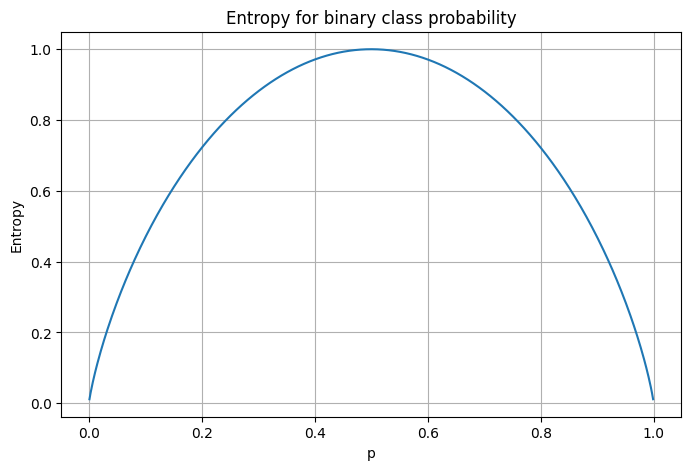

In [33]:
import numpy as np
p = np.linspace(0.001, 0.999, 500)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

plt.figure(figsize=(8, 5))
plt.plot(p, entropy)
plt.title("Entropy for binary class probability")
plt.xlabel("p")
plt.ylabel("Entropy")
plt.grid(True)
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("X shape:", X_iris.shape)
print("y shape:", y_iris.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


![Iris data](iris_data.png)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

In [36]:
iris_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

iris_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [37]:
y_pred = iris_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



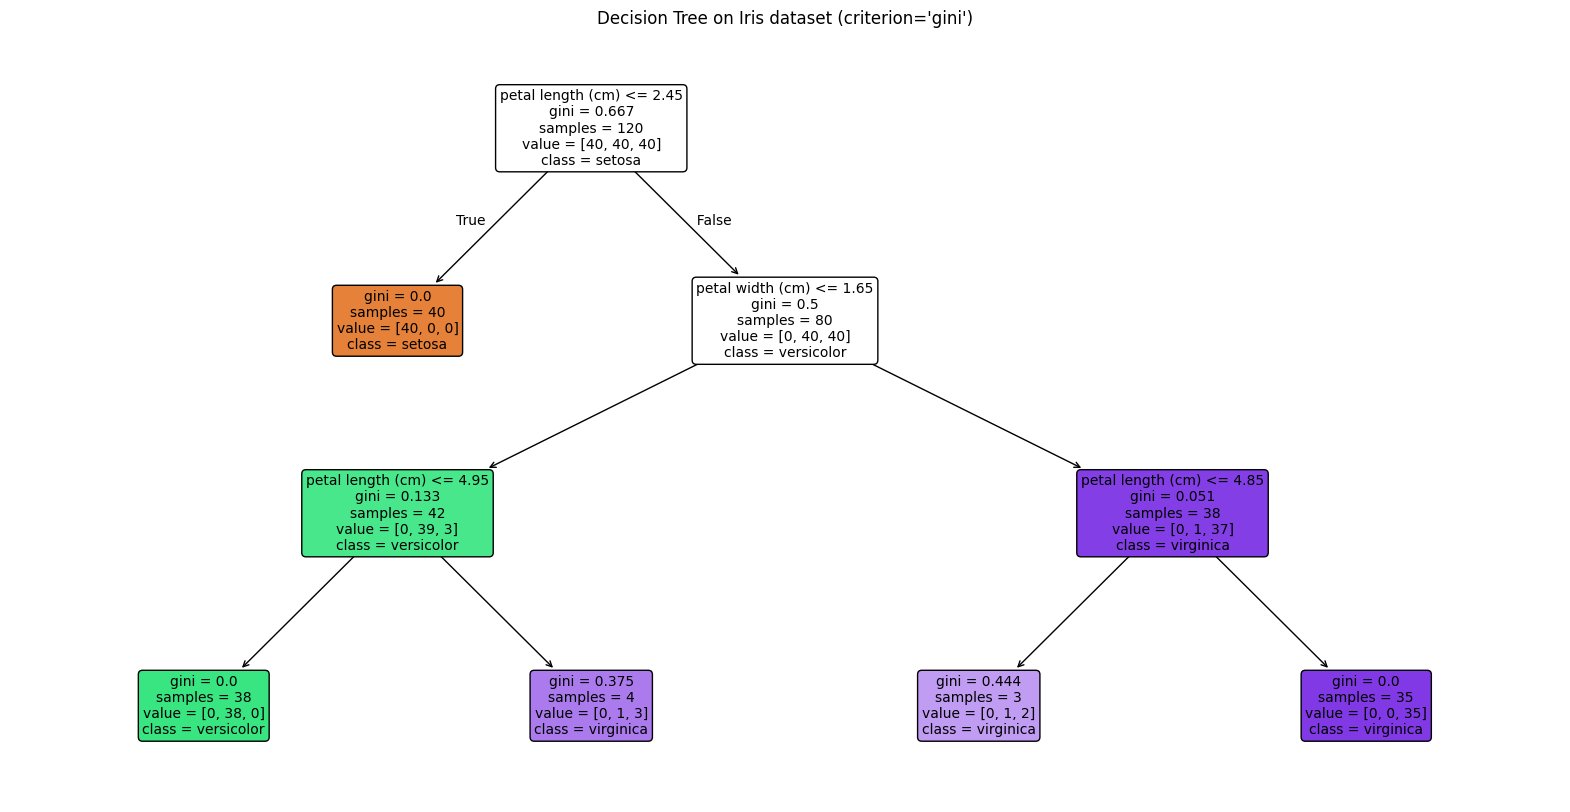

In [38]:
plt.figure(figsize=(20, 10))
plot_tree(
    iris_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree on Iris dataset (criterion='gini')")
plt.show()

In [39]:
iris_sample = X_test[0].reshape(1, -1)
pred_class = iris_model.predict(iris_sample)[0]
pred_name = iris.target_names[pred_class]

print("Sample features:", iris_sample)
print("Predicted class:", pred_name)

path = iris_model.decision_path(iris_sample)
leaf = iris_model.apply(iris_sample)[0]

print("Decision path node ids:", path.indices)
print("Leaf node id:", leaf)

Sample features: [[4.4 3.  1.3 0.2]]
Predicted class: setosa
Decision path node ids: [0 1]
Leaf node id: 1


## 12. Pruning nima?

Agar daraxt juda chuqur bo‘lib ketsa, u data ni yodlab olishi mumkin.

Bu esa `overfitting` ga olib keladi.

Shuning uchun `pruning` ishlatiladi.

**Pruning** — keraksiz shoxlarni kesish.

Maqsad:
- modelni soddalashtirish
- umumlashtirishni yaxshilash
- overfitting ni kamaytirish

Demak, har doim katta daraxt yaxshi degani emas.
Ba’zan kichik va to‘g‘ri kesilgan daraxt yaxshiroq ishlaydi.

![Iris data](pruned_model_iris.png)

## 20. `depth` va `overfitting`

`Depth` oshgan sari daraxt ko‘proq savol beradi.

Bu ikkita holatga olib kelishi mumkin:

### Yaxshi tomoni:
- model murakkab pattern larni o‘rganadi

### Yomon tomoni:
- model training data ni yodlab oladi
- yangi data da yomon ishlashi mumkin

Shuning uchun `max_depth`, `min_samples_leaf`, `min_samples_split` kabi cheklovlar ishlatiladi.

## 21. Decision Tree ning afzalliklari

Decision Tree ning kuchli tomonlari:

- tushunish oson
- vizual ko‘rinishi bor
- category va numeric data bilan ishlay oladi
- izohlash qulay
- qoidalarni odamga tushuntirish oson

Shuning uchun bu model boshlang‘ich ML darslarida juda yaxshi tanlov hisoblanadi.

## 22. Decision Tree ning kamchiliklari

Har bir modelning kamchiligi bo‘lgani kabi, Decision Tree ning ham kamchiliklari bor:

- `overfitting` ga moyil
- kichik data o‘zgarishiga sezgir
- ba’zan barqaror emas
- juda chuqur daraxt tushunishni qiyinlashtiradi

Shu sababli ba’zan `pruning` yoki ensemble metodlar ishlatiladi.